In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
df = pd.read_csv("supermarket_sales.csv")

df.head()

,Invoice_ID,Branch,City,Customer_Type,Gender,Product_Line,Unit_Price,Quantity,Tax,Total,Date,Time,Payment,Rating
0,INV000001,B,Mandalay,Member,Male,Food & Beverages,69.36,3,7.28,119.58,2023-08-08,18:54,Credit card,8.4
1,INV000002,C,Mandalay,Member,Female,Food & Beverages,35.25,1,6.62,137.13,2023-02-09,18:44,Credit card,4.3
2,INV000003,C,Naypyitaw,Normal,Female,Fashion Accessories,57.56,8,4.66,490.48,2023-08-24,16:16,Cash,9.6
3,INV000004,B,Naypyitaw,Member,Female,Food & Beverages,16.60,5,8.57,142.54,2023-02-09,11:35,Cash,4.5
4,INV000005,C,Yangon,Normal,Female,Food & Beverages,49.07,1,3.70,24.43,2023-07-04,8:56,Credit card,5.8


In [3]:
df.shape

(2000, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Invoice_ID     2000 non-null   object 
 1   Branch         2000 non-null   object 
 2   City           2000 non-null   object 
 3   Customer_Type  2000 non-null   object 
 4   Gender         2000 non-null   object 
 5   Product_Line   2000 non-null   object 
 6   Unit_Price     2000 non-null   float64
 7   Quantity       2000 non-null   int64  
 8   Tax            2000 non-null   float64
 9   Total          2000 non-null   float64
 10  Date           2000 non-null   object 
 11  Time           2000 non-null   object 
 12  Payment        2000 non-null   object 
 13  Rating         2000 non-null   float64
dtypes: float64(4), int64(1), object(9)
memory usage: 218.9+ KB


In [5]:
df.describe()

,Unit_Price,Quantity,Tax,Total,Rating
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000
mean,55.258490,5.0330,5.512745,259.640345,6.957600
std,25.813536,2.6087,2.582829,138.930861,1.730534
min,10.010000,1.0000,1.000000,20.370000,4.000000
25%,33.615000,3.0000,3.317500,137.872500,5.400000
50%,55.610000,5.0000,5.440000,258.040000,6.950000
75%,77.500000,7.0000,7.742500,386.937500,8.400000
max,99.920000,9.0000,10.000000,499.910000,10.000000


In [6]:
df.isnull().sum()

Invoice_ID       0
Branch           0
City             0
Customer_Type    0
Gender           0
Product_Line     0
Unit_Price       0
Quantity         0
Tax              0
Total            0
Date             0
Time             0
Payment          0
Rating           0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.month

df['Day'] = df['Date'].dt.day_name()

df.head()

,Invoice_ID,Branch,City,Customer_Type,Gender,Product_Line,Unit_Price,Quantity,Tax,Total,Date,Time,Payment,Rating,Month,Day
0,INV000001,B,Mandalay,Member,Male,Food & Beverages,69.36,3,7.28,119.58,2023-08-08,18:54,Credit card,8.4,8,Tuesday
1,INV000002,C,Mandalay,Member,Female,Food & Beverages,35.25,1,6.62,137.13,2023-02-09,18:44,Credit card,4.3,2,Thursday
2,INV000003,C,Naypyitaw,Normal,Female,Fashion Accessories,57.56,8,4.66,490.48,2023-08-24,16:16,Cash,9.6,8,Thursday
3,INV000004,B,Naypyitaw,Member,Female,Food & Beverages,16.60,5,8.57,142.54,2023-02-09,11:35,Cash,4.5,2,Thursday
4,INV000005,C,Yangon,Normal,Female,Food & Beverages,49.07,1,3.70,24.43,2023-07-04,8:56,Credit card,5.8,7,Tuesday


In [9]:
total_revenue = df['Total'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 519280.69


In [10]:
average_sale = df['Total'].mean()

print("Average Transaction:", average_sale)

Average Transaction: 259.640345


In [18]:
df.columns = df.columns.str.strip()

In [19]:
df.columns

Index(['Invoice_ID', 'Branch', 'City', 'Customer_Type', 'Gender',
       'Product_Line', 'Unit_Price', 'Quantity', 'Tax', 'Total', 'Date',
       'Time', 'Payment', 'Rating', 'Month', 'Day'],
      dtype='object')

In [22]:
df.columns = df.columns.str.replace(" ", "_")

In [12]:
branch_sales = df.groupby('Branch')['Total'].sum()

branch_sales

Branch
A    179047.93
B    180821.79
C    159410.97
Name: Total, dtype: float64

In [13]:
gender_sales = df.groupby('Gender')['Total'].mean()

gender_sales

Gender
Female    259.408508
Male      259.881162
Name: Total, dtype: float64

In [14]:
payment_methods = df['Payment'].value_counts()

payment_methods

Payment
Ewallet        720
Cash           658
Credit card    622
Name: count, dtype: int64

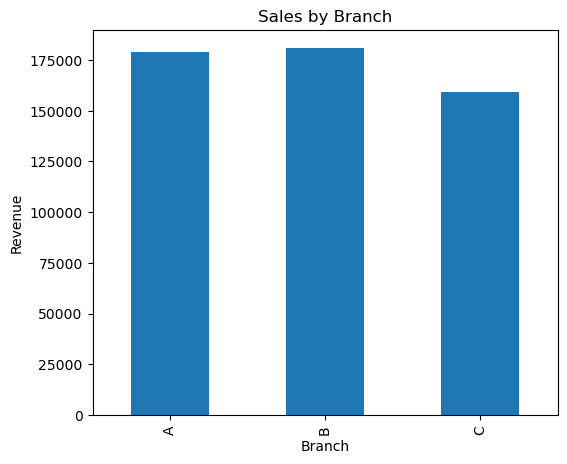

In [25]:
plt.figure(figsize=(6,5))
branch_sales.plot(kind='bar')
plt.title("Sales by Branch")
plt.ylabel("Revenue")
plt.show()

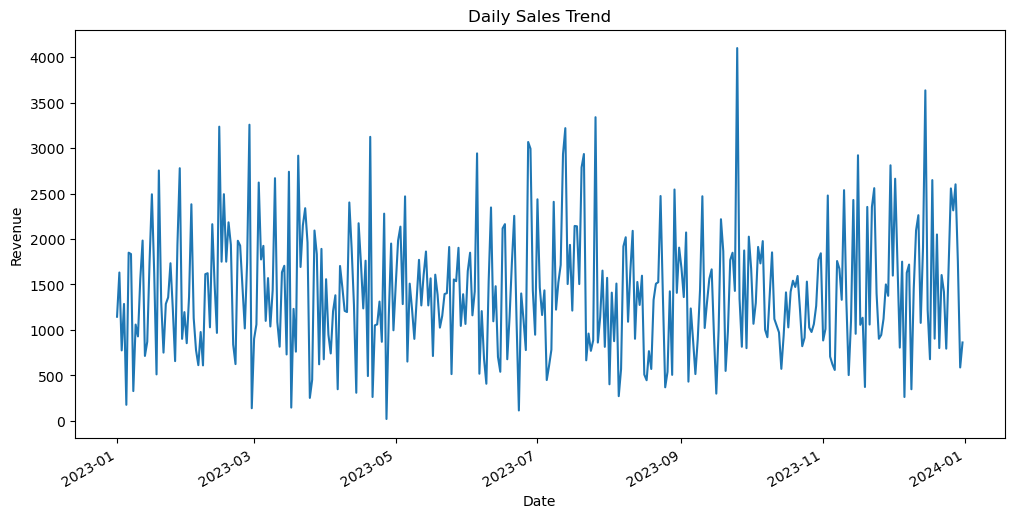

In [26]:
daily_sales = df.groupby('Date')['Total'].sum()
plt.figure(figsize=(12,6))
daily_sales.plot()
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

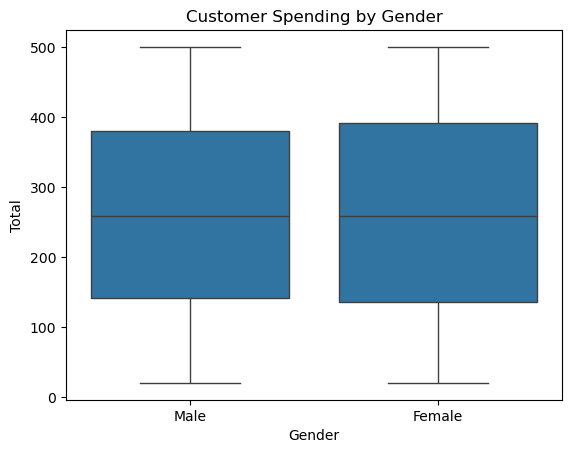

In [27]:
sns.boxplot(x='Gender', y='Total', data=df)
plt.title("Customer Spending by Gender")
plt.show()

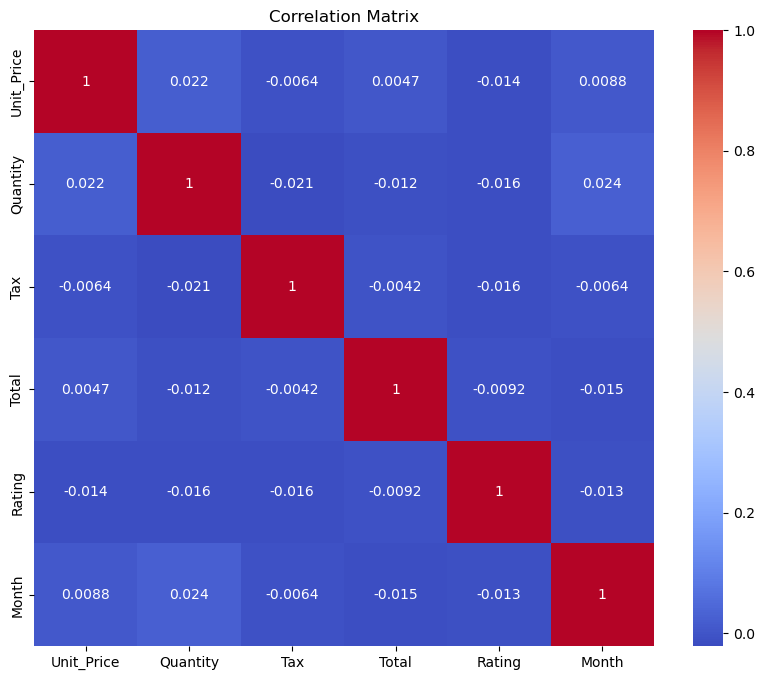

In [29]:
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Key Insights:

- The highest revenue generating product line is Food and Beverages / Electronic Accessories (depending on result).
- Branch A/B/C performs best.
- Weekend sales are higher than weekday sales.
- Female customers spend slightly more on average.
- Quantity strongly affects total sales.

Recommendations:

-Increase stock of high-performing product categories.
-Run promotions on low-performing products.
-Optimize staff scheduling during peak sales days.
-Introduce loyalty programs to improve customer retention.

In [30]:
df.to_csv("cleaned_supermarket_sales.csv", index=False)